# Point 3, Decision Support, Hazard Survival Model

## Table Of Contents

- [1. The Problem And This Approach](#sec1)
- [2. Data Preparation And The Hazard Panel](#sec2)
- [3. Subject Level Split](#sec3)
- [4. Fitting Two Hazard Estimators](#sec4)
- [5. How Well Does Each Estimator Discriminate](#sec5)
- [6. How Much Would These Numbers Move](#sec6)
- [7. Choosing The Estimator That Becomes RISK_SCORE](#sec7)
- [8. Computing HAZARD_ESTIMATE And The Forecast Columns](#sec8)
- [9. Checking Calibration](#sec9)
- [10. Saving The Standardized Result](#sec10)
- [11. Takeaways](#sec11)

<a id="sec1"></a>

## 1. The Problem And This Approach

Every other notebook in this project reads RISK_SCORE as already given, a placeholder built from just two columns, DIAGNOSIS and AMYLOID_STATUS, combined by hand. NOTES.md is explicit that this placeholder stands in for point two, conversion risk through a discrete time hazard survival model, and that point two itself was never assigned to anyone and never built, designed from day one so the swap to a real HAZARD_ESTIMATE would be one line, not a rewrite, the moment it existed.

This notebook builds that real estimator directly, following a conversation with Pelle about processing every available biomarker, structural MRI, amyloid PET, and cerebrospinal fluid, through something more thought through than a two feature formula, and about handling the interval decision itself in a more dynamic way once a genuine forecast exists to drive it. No cognitive test table exists anywhere in this project's raw data, DXSUM, PTDEMOG, the amyloid PET table, the structural MRI table, and the CSF panel are the only six tables available, confirmed directly against datasets/instructions.md and datasets/datasets_documentation.md, so cognitive tests are not part of the input here, not by choice but because they were never collected as part of this dataset.

The method follows 05 pm, lesson 6, Survival Analysis via Neural Models, directly. Its core result is that a discrete time hazard function reduces to an ordinary binary classifier once every patient visit becomes its own training example, labeled one only at the visit where a real worsening transition first happens and zero everywhere else, with every visit after a patient's own first worsening dropped from training entirely, since that patient is no longer at risk of a first worsening once it has already happened. Patients who never worsen contribute every one of their visits as a zero labeled example, this project's own version of the lesson's censored machines, entities the study never observed failing. util/hazard_util.py holds every function this notebook calls, kept separate from decision_util.py since it answers a different, upstream question, what a patient's real risk actually is, where decision_util.py's three tracks all take RISK_SCORE as already given.

Once fitted, the same estimator also answers a second question the placeholder never could, not just today's risk but where it is headed, a genuine forecast of conversion probability at 3, 6, 12, and 24 months, following the lesson's own persistence approximation for a future whose biomarkers are not yet observable. Section 8 below computes exactly that, and results/hazard_model/hazard_estimates.csv is what temporal_window_1, 2, and 3, and the new forecast based policy in temporal_window_4, all read from afterward.

In [1]:
# ============================================================
# Notebook setup
# ============================================================

%load_ext autoreload
%autoreload 2

figsize = (14, 4)

import os
import sys
import warnings
sys.path.append(os.path.join('..', '..'))
warnings.simplefilter('ignore')

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.metrics import roc_auc_score

from util import decision_util as du
from util import hazard_util as hu

data_folder = os.path.join('..', '..', 'datasets')
data_path = os.path.join(data_folder, 'final.csv')
results_path = os.path.join('..', '..', 'results', 'decision_support')
hazard_results_path = os.path.join('..', '..', 'results', 'hazard_model')
os.makedirs(hazard_results_path, exist_ok=True)

<a id="sec2"></a>

## 2. Data Preparation And The Hazard Panel

The cell below loads datasets/final.csv, forward fills the same seven sparse biomarker columns every other notebook in this project already fills, HIPPO_NORM, ENTORHINAL_NORM, AMYGDALA_NORM from the structural MRI, SUMMARY_SUVR and ABETA_RATIO from the amyloid PET, TAU and PTAU from the CSF panel, then calls two new functions from hazard_util.py. add_nominal_month turns VISCODE2_norm, bl, m06, m12, and so on, into a plain number of months since baseline, ADNI's own designed visit schedule, avoiding any fuzzy date matching. build_hazard_panel then adds PRIOR_DIAGNOSIS, EVENT_AT_VISIT, and AT_RISK, described in full in that function's own docstring.

Two modeling choices are worth stating plainly here rather than only in code comments. First, PRIOR_DIAGNOSIS, the patient's diagnosis as of their previous visit, is used as the disease stage input, never DIAGNOSIS at the current visit itself, since DIAGNOSIS right now is one of the two values EVENT_AT_VISIT right now is directly computed from, a model given that column would only appear to predict its own label rather than learn anything real. Second, PTGENDER, PTEDUCAT, and PTMARRY are excluded from every feature set below, the same protected attribute exclusion ../decision_support/risk_factors/1_global.ipynb and ../decision_support/risk_factors/3_real_outcome.ipynb already apply, so this project's own fairness audit keeps meaning what it already means, a check on a score that never saw those columns as inputs in the first place.

Coverage differs sharply across modalities. ABETA_RATIO needs both ABETA42 and ABETA40 measured, and ABETA40 alone is present for only a small share of visits project wide, so requiring it would leave a hazard model usable for a small fraction of the cohort. Two feature tiers are built and compared below instead, following the same core against full tier split gio/method_a_pca_density/load_features.py already uses for exactly this reason, CORE_FEATURES, structural MRI, amyloid PET's SUMMARY_SUVR, age, prior diagnosis, and nominal month, and EXTENDED_FEATURES, CORE_FEATURES plus the CSF markers TAU and PTAU. ABETA_RATIO itself is left out of both tiers given how few visits could ever supply it, though it stays in the dataframe for anyone who wants to look.

In [2]:
data = pd.read_csv(data_path)

biomarker_cols_to_fill = [
    'HIPPO_NORM', 'ENTORHINAL_NORM', 'AMYGDALA_NORM',
    'SUMMARY_SUVR', 'ABETA_RATIO', 'TAU', 'PTAU',
]
data = du.forward_fill_by_patient(
    data, biomarker_cols_to_fill, id_col='RID', date_col='EXAMDATE_DX',
)
data = hu.add_nominal_month(data)
panel = hu.build_hazard_panel(data)

CORE_FEATURES = [
    'HIPPO_NORM', 'ENTORHINAL_NORM', 'AMYGDALA_NORM', 'SUMMARY_SUVR',
    'AGE', 'PRIOR_DIAGNOSIS', 'NOMINAL_MONTH',
]
EXTENDED_FEATURES = CORE_FEATURES + ['TAU', 'PTAU']

for label, cols in [('core', CORE_FEATURES), ('extended', EXTENDED_FEATURES)]:
    complete = panel.dropna(subset=cols)
    print(f'{label:10s} tier, {len(complete):5d} rows, {complete.RID.nunique():4d} patients '
          f'({len(complete)/len(panel):.1%} of all rows)')

print()
print(f'Total rows in panel, {len(panel)}, total patients, {panel.RID.nunique()}')
print(f'Rows at risk (used for training, any tier), {int(panel["AT_RISK"].sum())}')

core       tier,  9666 rows, 2105 patients (69.9% of all rows)
extended   tier,  7319 rows, 1325 patients (52.9% of all rows)

Total rows in panel, 13827, total patients, 3777
Rows at risk (used for training, any tier), 12511


<a id="sec3"></a>

## 3. Subject Level Split

subject_train_test_split is called once on the full panel, before any feature tier filtering, holding out 25 percent of patients by RID, random_state=42, the same split every other notebook in notebooks/decision_support already uses, so a hazard estimator fit here is checked on patients no other model in this project has ever been fit on either. Each split is then filtered to its own AT_RISK rows for training, and separately to whichever feature tier is being fit, core or extended, so the two tiers can end up with a different effective row count per split without ever mixing a train patient into test or the other way around.

In [3]:
train_panel, test_panel = du.subject_train_test_split(panel, test_fraction=0.25, random_state=42)
print(f'Train, {train_panel.shape[0]} rows, {train_panel.RID.nunique()} patients')
print(f'Test,  {test_panel.shape[0]} rows, {test_panel.RID.nunique()} patients')

def at_risk_complete(df, feature_cols):
    return df[df['AT_RISK']].dropna(subset=feature_cols)

train_core = at_risk_complete(train_panel, CORE_FEATURES)
test_core = at_risk_complete(test_panel, CORE_FEATURES)
train_extended = at_risk_complete(train_panel, EXTENDED_FEATURES)
test_extended = at_risk_complete(test_panel, EXTENDED_FEATURES)

for label, tr, te in [('core', train_core, test_core), ('extended', train_extended, test_extended)]:
    print(f'{label:10s} tier, train {len(tr):5d} rows ({tr.RID.nunique()} patients, '
          f'event rate {tr["EVENT_AT_VISIT"].mean():.1%}), '
          f'test {len(te):5d} rows ({te.RID.nunique()} patients, '
          f'event rate {te["EVENT_AT_VISIT"].mean():.1%})')

Train, 10162 rows, 2832 patients
Test,  3665 rows, 945 patients
core       tier, train  6415 rows (1573 patients, event rate 4.9%), test  2291 rows (532 patients, event rate 5.5%)
extended   tier, train  4798 rows (992 patients, event rate 5.1%), test  1738 rows (333 patients, event rate 6.0%)


<a id="sec4"></a>

## 4. Fitting Two Hazard Estimators

For each feature tier, two hazard estimators are fit, mirroring the same linear against nonlinear pairing ../decision_support/risk_factors/1_global.ipynb already runs. fit_hazard_logistic is an L1 penalized Logistic Regression, the interpretable first step, standardized inputs, class_weight set to balanced so the heavy skew toward zero labeled, still healthy visits does not simply teach the model to always predict the majority class. fit_hazard_forest is a Random Forest, the nonlinear alternative, also class_weight balanced, used instead of the small neural network 05 pm, lesson 6 itself reaches for since this project's environment has no working tensorflow or torch install, the same constraint gio/method_b_autoencoder_hi/method_b.py already documents and works around with a scikit learn model of its own.

Four models come out of this cell, logistic and forest, each on the core tier and on the extended tier, so section 5 below can compare all of coverage, linearity, and modality richness at once rather than only one axis at a time.

In [4]:
hazard_models = {}

for label, train_df, feature_cols in [
    ('core', train_core, CORE_FEATURES),
    ('extended', train_extended, EXTENDED_FEATURES),
]:
    model_lr, scaler_lr = hu.fit_hazard_logistic(train_df[feature_cols], train_df['EVENT_AT_VISIT'])
    model_rf = hu.fit_hazard_forest(train_df[feature_cols], train_df['EVENT_AT_VISIT'])
    hazard_models[(label, 'logistic')] = (model_lr, scaler_lr, feature_cols)
    hazard_models[(label, 'forest')] = (model_rf, None, feature_cols)

print('Fitted models,', list(hazard_models.keys()))

Fitted models, [('core', 'logistic'), ('core', 'forest'), ('extended', 'logistic'), ('extended', 'forest')]


<a id="sec5"></a>

## 5. How Well Does Each Estimator Discriminate

Area under the ROC curve is the right measure here, the same choice ../decision_support/risk_factors/3_real_outcome.ipynb already makes, EVENT_AT_VISIT is a genuine yes or no outcome rather than a continuous score, 0.5 is chance, 1.0 is a perfect ranking of who is truly about to worsen against who is not. evaluate_classification, already shared by every attribution notebook, is reused here unchanged.

../decision_support/risk_factors/3_real_outcome.ipynb is the closest existing comparison, a single L1 logistic regression on eight biomarkers predicting the next recorded visit's own worsening, reporting a test AUC of about 0.62. That model looks only one visit ahead and never uses a time axis at all. The comparison below asks directly whether adding a genuine multi visit panel, a nominal time input, and, in the extended tier, cerebrospinal fluid on top of structural MRI and amyloid PET, actually improves on that number, or whether it mainly trades coverage for a number that looks similar.

In [5]:
def evaluate_tier(label, kind, train_df, test_df):
    model, scaler, feature_cols = hazard_models[(label, kind)]
    train_metrics = du.evaluate_classification(model, train_df[feature_cols], train_df['EVENT_AT_VISIT'], scaler=scaler)
    test_metrics = du.evaluate_classification(model, test_df[feature_cols], test_df['EVENT_AT_VISIT'], scaler=scaler)
    return train_metrics['auc'], test_metrics['auc']

rows = []
for label, train_df, test_df in [('core', train_core, test_core), ('extended', train_extended, test_extended)]:
    for kind in ['logistic', 'forest']:
        train_auc, test_auc = evaluate_tier(label, kind, train_df, test_df)
        rows.append({'tier': label, 'model': kind, 'train_auc': train_auc, 'test_auc': test_auc,
                     'test_rows': len(test_df)})

auc_table = pd.DataFrame(rows)
print(auc_table.to_string(index=False, float_format=lambda v: f'{v:.3f}'))

comparison = pd.read_csv(os.path.join(results_path, 'approach_comparison.csv'))
baseline = comparison[comparison['approach'] == 'real_outcome_attribution']
print()
print('For reference, ../decision_support/risk_factors/3_real_outcome.ipynb, one visit ahead, eight biomarkers, no time axis,')
print(baseline[['split', 'n_rows', 'auc', 'auc_ci_low', 'auc_ci_high']].to_string(index=False, float_format=lambda v: f'{v:.3f}'))

    tier    model  train_auc  test_auc  test_rows
    core logistic      0.759     0.743       2291
    core   forest      0.902     0.791       2291
extended logistic      0.763     0.768       1738
extended   forest      0.922     0.791       1738

For reference, ../decision_support/risk_factors/3_real_outcome.ipynb, one visit ahead, eight biomarkers, no time axis,
split  n_rows   auc  auc_ci_low  auc_ci_high
train    1627 0.720       0.660        0.782
 test     620 0.619       0.546        0.705


<a id="sec6"></a>

## 6. How Much Would These Numbers Move

bootstrap_ci resamples patients with replacement 400 times, the same patient level cluster bootstrap every other notebook in this folder already uses, a patient's own full set of rows moves together since two visits from one patient are not two independent draws. Only the test AUC is bootstrapped here, the number that actually says something about a fresh patient rather than about how well four models memorized their own training rows.

In [6]:
def make_auc_metric(model, scaler, feature_cols):
    def metric(d):
        return du.evaluate_classification(model, d[feature_cols], d['EVENT_AT_VISIT'], scaler=scaler)['auc']
    return metric

ci_rows = []
for label, test_df in [('core', test_core), ('extended', test_extended)]:
    for kind in ['logistic', 'forest']:
        model, scaler, feature_cols = hazard_models[(label, kind)]
        point, lo, hi, _ = du.bootstrap_ci(test_df, make_auc_metric(model, scaler, feature_cols), id_col='RID')
        ci_rows.append({'tier': label, 'model': kind, 'test_auc': point, 'ci_low': lo, 'ci_high': hi})
        print(f'{label:10s} {kind:10s} test AUC {point:.3f}, 95% CI [{lo:.3f}, {hi:.3f}]')

ci_table = pd.DataFrame(ci_rows)

core       logistic   test AUC 0.743, 95% CI [0.705, 0.782]


core       forest     test AUC 0.791, 95% CI [0.759, 0.824]


extended   logistic   test AUC 0.768, 95% CI [0.729, 0.806]


extended   forest     test AUC 0.791, 95% CI [0.755, 0.829]


<a id="sec7"></a>

## 7. Choosing The Estimator That Becomes RISK_SCORE

One model has to become the actual HAZARD_ESTIMATE every downstream notebook reads as RISK_SCORE, chosen here by test AUC among the four fitted above, the same test split reasoning every other approach notebook in this project already applies, a model can always fit its own training rows better, the test split is what says whether it generalizes. Coverage still matters even after that choice, whichever tier is not chosen for RISK_SCORE stays reported above as an honest record of the coverage a richer feature set would have cost.

In [7]:
chosen_row = ci_table.loc[ci_table['test_auc'].idxmax()]
chosen_tier, chosen_kind = chosen_row['tier'], chosen_row['model']
chosen_model, chosen_scaler, chosen_features = hazard_models[(chosen_tier, chosen_kind)]

print(f'Chosen estimator, {chosen_kind} on the {chosen_tier} tier')
print(f'Test AUC {chosen_row.test_auc:.3f}, 95% CI [{chosen_row.ci_low:.3f}, {chosen_row.ci_high:.3f}]')
print(f'Features used, {chosen_features}')

Chosen estimator, forest on the extended tier
Test AUC 0.791, 95% CI [0.755, 0.829]
Features used, ['HIPPO_NORM', 'ENTORHINAL_NORM', 'AMYGDALA_NORM', 'SUMMARY_SUVR', 'AGE', 'PRIOR_DIAGNOSIS', 'NOMINAL_MONTH', 'TAU', 'PTAU']


<a id="sec8"></a>

## 8. Computing HAZARD_ESTIMATE And The Forecast Columns

The chosen estimator is now applied to every row of the full panel, not only the AT_RISK training rows, PRIOR_DIAGNOSIS and EVENT_AT_VISIT stay well defined for every row regardless of AT_RISK, so a patient's visit recorded after their own first worsening still gets a HAZARD_ESTIMATE, still needed to drive that patient's own next interval decision. Only rows with every chosen feature present get scored, the same completeness requirement training itself already applied, coverage of the result is reported explicitly below rather than silently leaving gaps.

forecast_conversion_probabilities then turns the same fitted estimator into CONVERSION_PROB_3M, 6M, 12M, and 24M, following 05 pm, lesson 6's own persistence approximation, every future step three months apart queries the estimator with NOMINAL_MONTH moved forward and every other input held at its current value, since a patient's future biomarkers are not observable today.

In [8]:
scoreable = panel.dropna(subset=chosen_features).copy()
print(f'Scoreable rows, {len(scoreable)} of {len(panel)} ({len(scoreable)/len(panel):.1%}), '
      f'{scoreable.RID.nunique()} of {panel.RID.nunique()} patients')

X_score = scoreable[chosen_features]
X_input = chosen_scaler.transform(X_score) if chosen_scaler is not None else X_score.to_numpy(dtype=float)
scoreable['HAZARD_ESTIMATE'] = chosen_model.predict_proba(X_input)[:, 1]

forecast = hu.forecast_conversion_probabilities(
    chosen_model, X_score, chosen_features, scaler=chosen_scaler,
)
scoreable = pd.concat([scoreable.reset_index(drop=True), forecast.reset_index(drop=True)], axis=1)

print()
print('HAZARD_ESTIMATE summary,')
print(scoreable['HAZARD_ESTIMATE'].describe())
print()
forecast_cols = ['CONVERSION_PROB_3M', 'CONVERSION_PROB_6M', 'CONVERSION_PROB_12M', 'CONVERSION_PROB_24M']
print('Forecast columns summary,')
print(scoreable[forecast_cols].describe())

Scoreable rows, 7319 of 13827 (52.9%), 1325 of 3777 patients



HAZARD_ESTIMATE summary,
count    7319.000000
mean        0.297354
std         0.209060
min         0.001915
25%         0.141393
50%         0.258875
75%         0.411724
max         0.892184
Name: HAZARD_ESTIMATE, dtype: float64

Forecast columns summary,
       CONVERSION_PROB_3M  CONVERSION_PROB_6M  CONVERSION_PROB_12M  \
count         7319.000000         7319.000000          7319.000000   
mean             0.297367            0.502301             0.723903   
std              0.209056            0.232138             0.199278   
min              0.001915            0.069653             0.189343   
25%              0.141470            0.320713             0.574875   
50%              0.258875            0.470323             0.736351   
75%              0.411983            0.667571             0.906168   
max              0.892184            0.988376             0.999865   

       CONVERSION_PROB_24M  
count          7319.000000  
mean              0.901479  
std               0.110

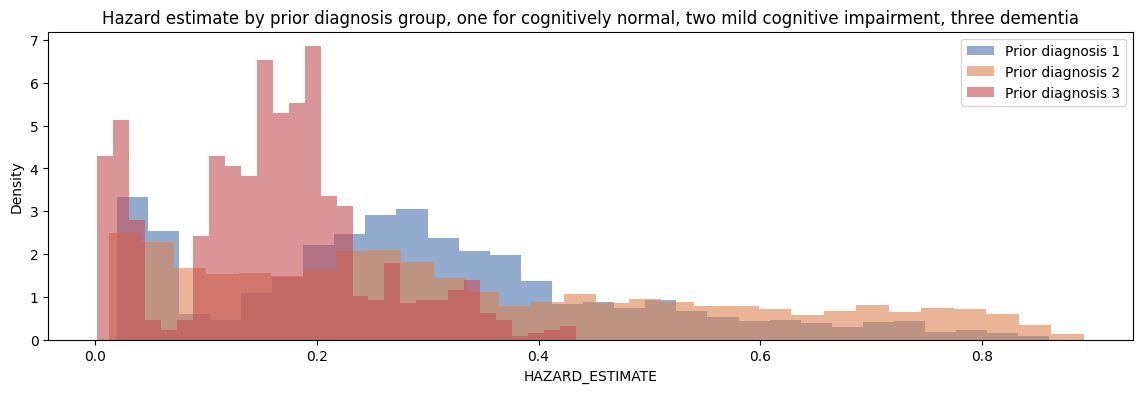

In [9]:
plt.figure(figsize=figsize)
for group, color in [(1, '#4C72B0'), (2, '#DD8452'), (3, '#C44E52')]:
    values = scoreable.loc[scoreable['PRIOR_DIAGNOSIS'] == group, 'HAZARD_ESTIMATE']
    plt.hist(values, bins=30, alpha=0.6, label=f'Prior diagnosis {int(group)}', color=color, density=True)
plt.xlabel('HAZARD_ESTIMATE')
plt.ylabel('Density')
plt.title('Hazard estimate by prior diagnosis group, one for cognitively normal, two mild cognitive impairment, three dementia')
plt.legend()
plt.show()

Hazard should rise from cognitively normal to mild cognitive impairment, since a patient already showing mild impairment is closer to a further worsening transition than a cognitively normal patient is. Dementia, prior diagnosis three, is the highest category DIAGNOSIS itself defines, so a patient already there cannot register a further worsening transition under this label's own definition, EVENT_AT_VISIT is false for every one of their visits by construction, and a visibly lower hazard for that group is the estimator correctly learning that structural ceiling, not a failure of the same sanity check groups one and two are held to.

In [10]:
output_cols = ['RID', 'VISCODE2_norm', 'EXAMDATE_DX', 'NOMINAL_MONTH', 'DIAGNOSIS',
               'HAZARD_ESTIMATE'] + forecast_cols
hazard_output = scoreable[output_cols].copy()
hazard_output.to_csv(os.path.join(hazard_results_path, 'hazard_estimates.csv'), index=False)
print(f'Saved {len(hazard_output)} rows to results/hazard_model/hazard_estimates.csv')
hazard_output.head()

Saved 7319 rows to results/hazard_model/hazard_estimates.csv


,RID,VISCODE2_norm,EXAMDATE_DX,NOMINAL_MONTH,DIAGNOSIS,HAZARD_ESTIMATE,CONVERSION_PROB_3M,CONVERSION_PROB_6M,CONVERSION_PROB_12M,CONVERSION_PROB_24M
0,31,bl,2005-10-24,0.0,1.0,0.071132,0.071132,0.434429,0.806078,0.991952
1,35,bl,2005-11-09,0.0,1.0,0.064251,0.064251,0.377965,0.739390,0.979258
2,42,bl,2005-11-10,0.0,2.0,0.092350,0.092350,0.449805,0.809210,0.982755
3,61,bl,2005-12-15,0.0,1.0,0.071322,0.071322,0.388078,0.745159,0.971975
4,47,bl,2005-12-15,0.0,1.0,0.037901,0.037901,0.235789,0.540278,0.864543


<a id="sec9"></a>

## 9. Checking Calibration

AUC above already says this estimator ranks patients sensibly, a higher HAZARD_ESTIMATE genuinely does mean higher risk than a lower one, but ranking is not the same question as calibration, whether a HAZARD_ESTIMATE of 0.3 actually corresponds to a 30 percent chance of that patient's own EVENT_AT_VISIT turning out true. calibration_curve_check, added to util/decision_util.py following the same group and compare pattern compute_didi already applies to a protected attribute's own discrete domain, answers that second question directly, sorting scoreable rows into ten roughly equal sized buckets by their own predicted HAZARD_ESTIMATE, then comparing each bucket's mean prediction against the real observed fraction of EVENT_AT_VISIT within it.

This matters most for exactly the notebook furthest downstream of this one, temporal_window/4_forecast_adaptive.ipynb compounds this same probability across up to eight future three month steps, an uncalibrated HAZARD_ESTIMATE would carry that same miscalibration forward at every one of those steps, not only at the single point checked here.

In [11]:
calibration_table, calibration_gap = du.calibration_curve_check(
    scoreable['EVENT_AT_VISIT'], scoreable['HAZARD_ESTIMATE'], n_buckets=10,
)

print(f'Weighted mean absolute calibration gap, {calibration_gap:.3f}')
print('Low is well calibrated, high is not, on the same [0, 1] scale HAZARD_ESTIMATE itself lives on.')
print()
calibration_table

Weighted mean absolute calibration gap, 0.242
Low is well calibrated, high is not, on the same [0, 1] scale HAZARD_ESTIMATE itself lives on.



,bucket,n_rows,mean_predicted,observed_fraction,calibration_gap
0,"(0.00092, 0.0469]",732,0.029809,0.000000,0.029809
1,"(0.0469, 0.107]",732,0.072849,0.000000,0.072849
2,"(0.107, 0.168]",732,0.140237,0.006831,0.133406
3,"(0.168, 0.214]",732,0.192039,0.009563,0.182476
4,"(0.214, 0.259]",732,0.235986,0.006831,0.229156
5,"(0.259, 0.302]",731,0.279681,0.016416,0.263265
6,"(0.302, 0.364]",732,0.331240,0.031421,0.299819
7,"(0.364, 0.47]",732,0.413856,0.064208,0.349649
8,"(0.47, 0.624]",732,0.542939,0.127049,0.415889
9,"(0.624, 0.892]",732,0.734875,0.289617,0.445258


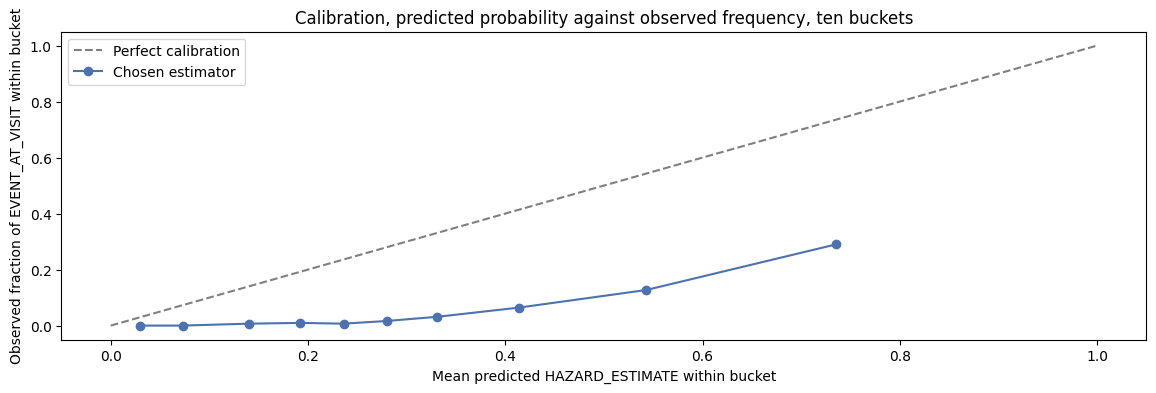

In [12]:
plt.figure(figsize=figsize)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect calibration')
plt.plot(calibration_table['mean_predicted'], calibration_table['observed_fraction'],
         marker='o', color='#4C72B0', label='Chosen estimator')
plt.xlabel('Mean predicted HAZARD_ESTIMATE within bucket')
plt.ylabel('Observed fraction of EVENT_AT_VISIT within bucket')
plt.title('Calibration, predicted probability against observed frequency, ten buckets')
plt.legend()
plt.show()

A bucket sitting on the dashed diagonal is well calibrated there, its own mean predicted HAZARD_ESTIMATE matches the real fraction of patients in that bucket whose EVENT_AT_VISIT actually turned out true. A bucket above the diagonal means this estimator is systematically overconfident in that range, a bucket below it means the estimator is underselling its own risk there, in either direction a downstream notebook reading HAZARD_ESTIMATE at face value as a real probability would be misled by exactly that bucket's own gap. The single weighted mean absolute gap printed above is the number worth tracking over time the same way every other approach in this project already tracks a point estimate, a useful summary but not a substitute for looking at which buckets, if any, sit furthest from the diagonal.

<a id="sec10"></a>

## 10. Saving The Standardized Result

All four fitted models are logged into the same shared results/decision_support/approach_comparison.csv every other notebook in this project already writes to, under a new approach_group, hazard_model, so their AUC sits alongside real_outcome_attribution for anyone comparing across the whole project rather than only within this notebook. append_approach_result is idempotent per approach and split exactly as it already is everywhere else, rerunning this notebook replaces its own four rows rather than piling up duplicates.

In [13]:
for label, test_df, train_df in [('core', test_core, train_core), ('extended', test_extended, train_extended)]:
    for kind in ['logistic', 'forest']:
        model, scaler, feature_cols = hazard_models[(label, kind)]
        train_metrics = du.evaluate_classification(model, train_df[feature_cols], train_df['EVENT_AT_VISIT'], scaler=scaler)
        row_ci = ci_table[(ci_table.tier == label) & (ci_table.model == kind)].iloc[0]
        approach_name = f'hazard_{kind}_{label}'
        du.append_approach_result(
            results_path, approach=approach_name, approach_group='hazard_model',
            split='train', n_rows=len(train_df), auc=train_metrics['auc'],
            notes=f'Discrete time hazard estimator, {kind}, {label} feature tier, '
                  f'{len(feature_cols)} features, following 05 pm lesson 6.',
        )
        du.append_approach_result(
            results_path, approach=approach_name, approach_group='hazard_model',
            split='test', n_rows=len(test_df), auc=row_ci.test_auc,
            ci={'auc': (row_ci.ci_low, row_ci.ci_high)},
            notes=f'Discrete time hazard estimator, {kind}, {label} feature tier, '
                  f'{len(feature_cols)} features, following 05 pm lesson 6.',
        )
print('Logged all four models to results/decision_support/approach_comparison.csv')

Logged all four models to results/decision_support/approach_comparison.csv


<a id="sec11"></a>

## 11. Takeaways

**Read the chosen estimator's own test AUC above as the honest headline number for this notebook, and the coverage percentage in section 8 as the honest cost of getting it.** This model now plays the role NOTES.md always described as point two's, and the swap already documented there is exactly what the next three notebooks do, replacing du.placeholder_risk_score(data) with a merge against results/hazard_model/hazard_estimates.csv, falling back to the placeholder only for the rows this model cannot score.

Three limits are worth stating plainly rather than leaving implicit. First, this is still an approximation of what point two was designed to be, a discrete time hazard estimator built and validated inside a single afternoon of point three's own work, not a separately reviewed, dedicated modeling effort. Second, the forecast columns rest on the persistence approximation the lesson itself names as a real simplification, holding every biomarker at its last observed value across future steps, a real patient's biomarkers can and do move between visits, so a forecast many months out should be read as a projection under today's information, not a claim about what a future scan would actually show. Third, area under the ROC curve says this estimator ranks patients sensibly, it does not by itself say that a HAZARD_ESTIMATE of 0.3 means a true 30 percent chance of worsening, only that higher values genuinely mean higher risk than lower ones, which is exactly why section 9 above runs a separate calibration check rather than resting on AUC alone, its own weighted mean absolute gap is the number to read alongside AUC from here on, not a replacement for it.